In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
df = pd.read_csv(r"C:\Users\MONSTER\OneDrive\Desktop\veri.csv\train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
print("Satır sayısı:",df.shape[0])
print("Sütun sayısı:",df.shape[1])
print("Sütun isimleri:",df.columns.tolist())
print("Veri tipleri:\n",df.dtypes)

Satır sayısı: 9800
Sütun sayısı: 18
Sütun isimleri: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
Veri tipleri:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [7]:
print("eksik değerler: \n", df.isnull().sum())

eksik değerler: 
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [8]:
df['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

In [9]:
fig=px.histogram(df,x="Sales",nbins=50,title="Satış Dağılımı")
fig.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv(r"C:\Users\MONSTER\OneDrive\Desktop\veri.csv\train.csv")
print("Veri yüklendi:", df.shape)


Veri yüklendi: (9800, 18)


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Order Date'].dtype


dtype('<M8[ns]')

In [5]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

fig = px.line(monthly_sales, x='YearMonth', y='Sales', title='Aylık Satış Trendi')
fig.show()

In [6]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

fig = px.bar(category_sales, x='Category', y='Sales', 
             title='Kategoriye Göre Toplam Satış',
             color='Category')
fig.show()

In [7]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
subcategory_sales = subcategory_sales.sort_values('Sales', ascending=False)

fig = px.bar(subcategory_sales, x='Sub-Category', y='Sales',
             title='Alt Kategoriye Göre Toplam Satış',
             color='Sales')
fig.show()

In [8]:
fig = px.box(df, y='Sales', title='Satış Aykırı Değer Analizi (Box Plot)')
fig.show()


In [9]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < alt_sinir) | (df['Sales'] > ust_sinir)]
print("Aykırı değer sayısı:", len(outliers))
print("Alt sınır:", round(alt_sinir, 2))
print("Üst sınır:", round(ust_sinir, 2))


Aykırı değer sayısı: 1145
Alt sınır: -272.79
Üst sınır: 500.64


In [10]:
import numpy as np

df['Sales_log'] = np.log1p(df['Sales'])

fig = px.histogram(df, x='Sales_log', nbins=50, title='Log Dönüşümü Sonrası Satış Dağılımı')
fig.show()

In [11]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales.columns = ['ds', 'y']
monthly_sales['ds'] = pd.to_datetime(monthly_sales['ds'].astype(str))

print(monthly_sales.head(10))
print("\nToplam ay sayısı:", len(monthly_sales))

          ds           y
0 2015-01-01  14205.7070
1 2015-02-01   4519.8920
2 2015-03-01  55205.7970
3 2015-04-01  27906.8550
4 2015-05-01  23644.3030
5 2015-06-01  34322.9356
6 2015-07-01  33781.5430
7 2015-08-01  27117.5365
8 2015-09-01  81623.5268
9 2015-10-01  31453.3930

Toplam ay sayısı: 48


In [12]:
fig = px.line(monthly_sales, x='ds', y='y', 
              title='Aylık Toplam Satış (Model Verisi)',
              labels={'ds': 'Tarih', 'y': 'Toplam Satış'})
fig.show()

In [13]:
train = monthly_sales[:-6]
test = monthly_sales[-6:]

print("Train boyutu:", len(train), "ay")
print("Test boyutu:", len(test), "ay")
print("\nTest dönemi:", test['ds'].min(), "→", test['ds'].max())

Train boyutu: 42 ay
Test boyutu: 6 ay

Test dönemi: 2018-07-01 00:00:00 → 2018-12-01 00:00:00


In [14]:
fig = px.line(title='Train / Test Ayrımı')
fig.add_scatter(x=train['ds'], y=train['y'], name='Train', line=dict(color='blue'))
fig.add_scatter(x=test['ds'], y=test['y'], name='Test', line=dict(color='red'))
fig.show()

In [15]:
monthly_sales['ay'] = monthly_sales['ds'].dt.month
monthly_sales['yil'] = monthly_sales['ds'].dt.year
monthly_sales['ceyrek'] = monthly_sales['ds'].dt.quarter

print(monthly_sales.head())


          ds          y  ay   yil  ceyrek
0 2015-01-01  14205.707   1  2015       1
1 2015-02-01   4519.892   2  2015       1
2 2015-03-01  55205.797   3  2015       1
3 2015-04-01  27906.855   4  2015       2
4 2015-05-01  23644.303   5  2015       2


In [16]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

model.fit(train)
print("Model eğitildi!")

12:14:35 - cmdstanpy - INFO - Chain [1] start processing
12:14:36 - cmdstanpy - INFO - Chain [1] done processing


Model eğitildi!


In [17]:
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

           ds          yhat    yhat_lower     yhat_upper
38 2018-03-01  62762.754218  54487.685574   71139.185689
39 2018-04-01  37960.976945  30193.354750   45414.332490
40 2018-05-01  42871.093412  34634.330655   50763.548753
41 2018-06-01  44428.016658  36453.245453   52346.829285
42 2018-07-01  40624.222107  32976.426997   48526.903332
43 2018-08-01  33220.531369  24656.357751   41460.964497
44 2018-09-01  92253.187246  84062.292593  100167.157046
45 2018-10-01  47709.453433  39848.154408   55207.778104
46 2018-11-01  95663.632228  86770.424837  103999.356738
47 2018-12-01  95625.492681  86745.335095  103589.927383


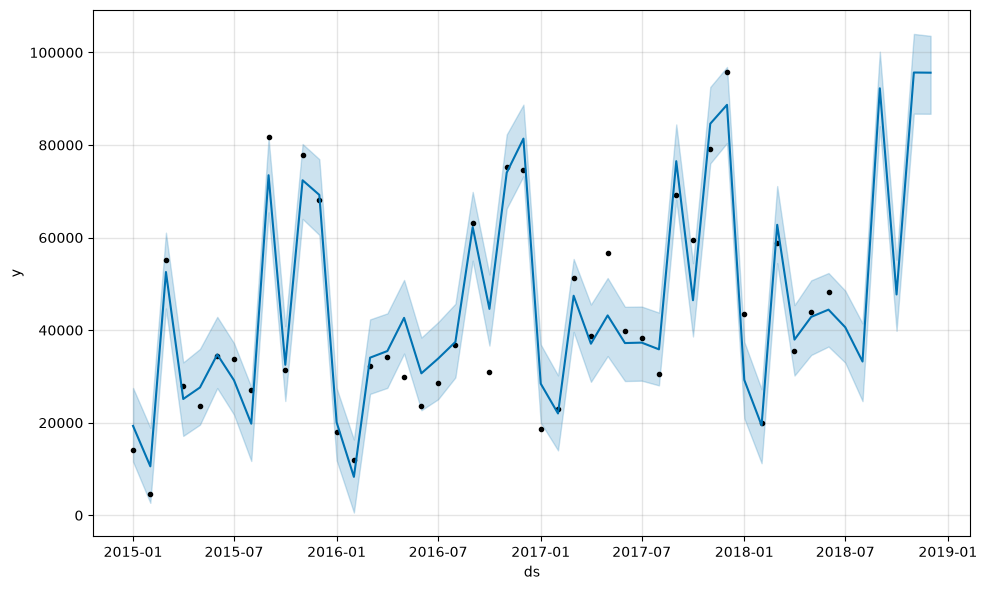

In [18]:
fig = model.plot(forecast)

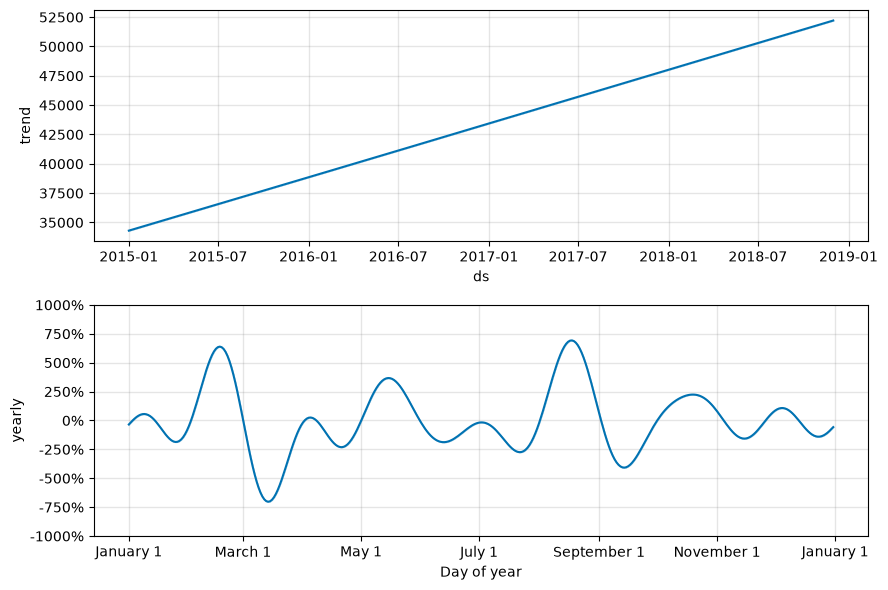

In [19]:
fig2 = model.plot_components(forecast)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

test_forecast = forecast[forecast['ds'].isin(test['ds'])]

mae = mean_absolute_error(test['y'], test_forecast['yhat'])
rmse = mean_squared_error(test['y'], test_forecast['yhat']) ** 0.5
mape = (abs(test['y'].values - test_forecast['yhat'].values) / test['y'].values).mean() * 100

print(f"MAE:  {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"MAPE: {mape:.1f}%")

MAE:  17,421
RMSE: 20,295
MAPE: 22.7%


In [21]:
fig = px.line(title='Prophet: Gerçek vs Tahmin')
fig.add_scatter(x=test['ds'], y=test['y'], name='Gerçek', line=dict(color='blue'))
fig.add_scatter(x=test_forecast['ds'], y=test_forecast['yhat'], name='Tahmin', line=dict(color='red', dash='dash'))
fig.show()

In [22]:
import mlflow

mlflow.set_experiment("sales-forecast")

with mlflow.start_run(run_name="prophet-v1"):
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mape", mape)
    mlflow.log_param("model", "Prophet")
    mlflow.log_param("test_months", 6)
    mlflow.log_param("seasonality_mode", "multiplicative")
    
    print("MLflow'a kaydedildi!")

2026/07/14 12:21:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/14 12:21:19 INFO mlflow.store.db.utils: Updating database tables
2026/07/14 12:21:21 INFO mlflow.tracking.fluent: Experiment with name 'sales-forecast' does not exist. Creating a new experiment.


MLflow'a kaydedildi!


In [23]:
import subprocess
subprocess.Popen(["mlflow", "ui"])
print("MLflow UI başlatıldı!")
print("Tarayıcıda aç: http://localhost:5000")

MLflow UI başlatıldı!
Tarayıcıda aç: http://localhost:5000
